# Importing libraries

In [ ]:
import pandas as pd
import scanpy as sc
import liana as li
import omnipath as op
seed = 0


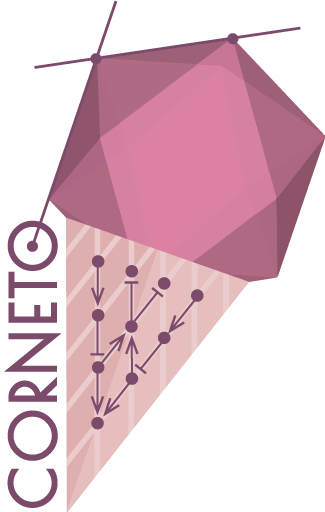

In [20]:
import corneto as cn
cn.info()

## Loading seq. data

/home/od/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


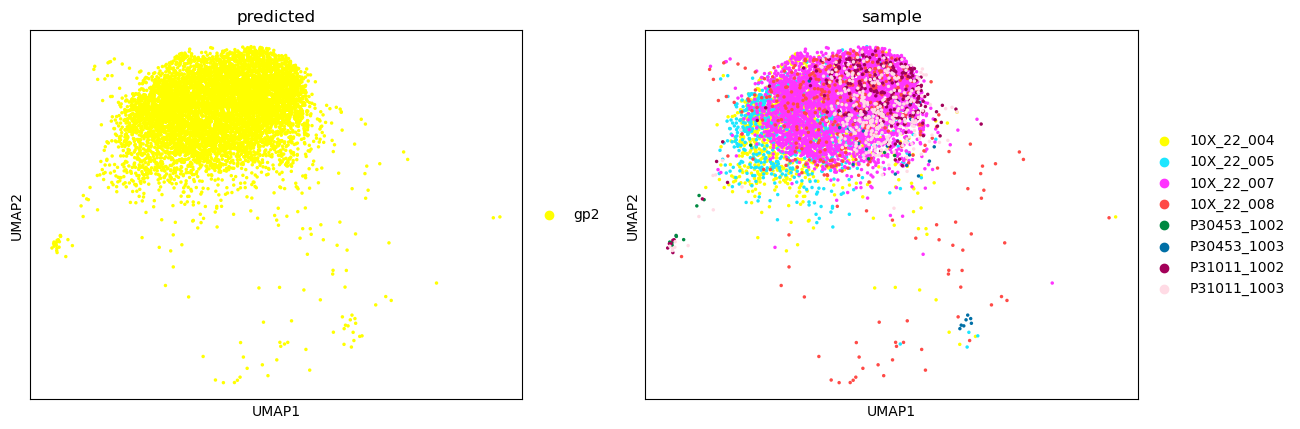

In [17]:
adata = sc.read('adata.h5ad')
clusters = 'predicted'
adata = adata[adata.obs[clusters].isin(['gp2'])]
adata = adata[adata.obs['treatment']!='unc']
sc.pl.umap(adata, color=[clusters, 'sample'], size=25, palette=sc.pl.palettes.godsnot_102)

## PPI network

In [7]:
ppis = op.interactions.OmniPath().get(genesymbols = True)

ppis['mor'] = ppis['is_stimulation'].astype(int) - ppis['is_inhibition'].astype(int)
ppis = ppis[(ppis['mor'] != 0) & (ppis['curation_effort'] >= 5) & ppis['consensus_direction']]

input_pkn = ppis[['source_genesymbol', 'mor', 'target_genesymbol','curation_effort','consensus_direction']]
input_pkn.columns = ['source', 'mor', 'target','curation_effort','consensus_direction']
input_pkn.head()

,source,mor,target,curation_effort,consensus_direction
3,CAV1,1,TRPC1,13,True
6,ITPR2,1,TRPC1,13,True
9,STIM1,1,TRPC1,22,True
10,TRPC1,1,TRPC3,15,True
11,TRPC3,1,TRPC1,15,True


## Provide the inputs

In [ ]:
input_scores = {'GHR':1}

## Provide (filtered) SCENIC outputs

In [11]:
regulons = pd.read_csv('regulons.csv', index_col=0)
print(regulons.shape)
regulons.head()

(113, 3)


,gh,veh,abdif
IRF1,0.101864,0.039232,0.062632
ZBTB7A,0.085775,0.032689,0.053086
ERF,0.080076,0.040849,0.039227
KLF7,0.065470,0.034523,0.030947
FOSL1,0.073095,0.052395,0.020700


In [12]:
output_scores = dict(regulons['abs_dif'].head(30)*100) | dict(regulons['abs_dif'].tail(30)*100)

## Prior graph

In [15]:
# convert the PPI network into a knowledge graph
prior_graph = li.mt.build_prior_network(input_pkn, input_scores, output_scores, verbose=True)

Importing network...
done.
 - Nodes x Edges: (3115, 6157)
 - Provided inputs included in the prior network: 1/1
 - Provided outputs included in the network: 36/60
Performing reachability analysis...
done.
 - Selected inputs: 1/1.
 - Selected outputs: 34/36.
 - Final size of the prior graph: (559, 2054).


## Node weights

In [19]:
node_weights = pd.DataFrame(adata.layers['counts'].getnnz(axis=0) / adata.n_obs, index=adata.var_names)
node_weights = node_weights.rename(columns={0: 'props'})
node_weights = node_weights['props'].to_dict()

## Run Corneto

In [28]:
%%time 

df_res, problem = li.mt.find_causalnet(
    prior_graph, 
    input_scores,
    output_scores,
    node_weights,
    node_cutoff=0.1,
    max_penalty=1,
    min_penalty=0.01,
    edge_penalty=0.1,
    verbose=False,
    max_runs=100, 
    stable_runs=10,
    solver='Gurobi',
    seed = seed
    )

Set parameter Username


Set parameter Username


Academic license - for non-commercial use only - expires 2025-07-23


Academic license - for non-commercial use only - expires 2025-07-23


CPU times: user 4min 27s, sys: 9.46 s, total: 4min 36s
Wall time: 29.3 s


## Visualize

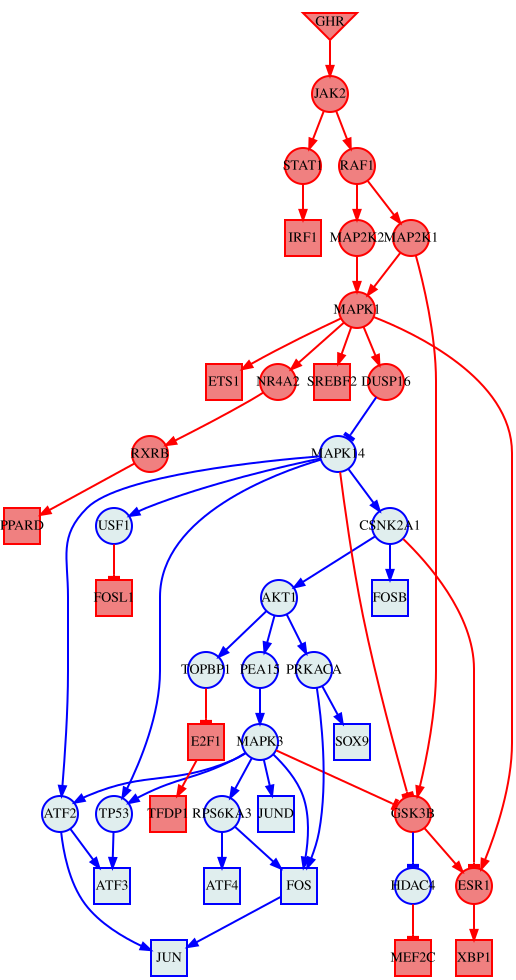

In [29]:
cn.methods.carnival.visualize_network(df_res.drop_duplicates(['source','target'])) # scenic liana# scenic_ol_liana (no cols and only positives)
# TFs30+30, adata gh, maxruns=60,stable=10